# Antispoofing

In this homework, you will develop a countermeasure against deepfakes and then try to explain it using various XAI techniques.

More specifically, you will implement and train a Countermeasure (CM) system on the Logical Access partition of the [ASVSpoof 2019 Dataset](https://datashare.ed.ac.uk/handle/10283/3336) ([Kaggle Link](https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset)). You may find the [ASVspoof 2019 evaluation plan](https://www.asvspoof.org/asvspoof2019/asvspoof2019_evaluation_plan.pdf) useful.

For the CM, we choose [LightCNN (LCCN)](https://arxiv.org/abs/1511.02683) that once achieved the top place in the competition. We will follow the Speech Technology Center (STC) [paper](https://arxiv.org/abs/1904.05576).

**Hints**:

1. Use STFT (FFT in the paper) as front-end.

2. The dropout layer is put before the last batch norm.

## Dataset [0.5 pts]

We want to train a neural network to predict if the input audio is real or fake. To do so, we need a dataset first. In this homework, we will work with [ASVspoof19](https://arxiv.org/pdf/1911.01601.pdf).

Create a `Dataset` class that downloads the dataset, parses its metadata and, given index $i$, returns $i$-th object of the dataset. Do not forget to preprocess audio for LCNN (calculate stft, etc.).

In [ ]:
!curl -L -o asvpoof-2019-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/awsaf49/asvpoof-2019-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 23.5G  100 23.5G    0     0  91.6M      0  0:04:23  0:04:23 --:--:-- 95.1M


In [ ]:
import zipfile

zip_path = '/content/asvpoof-2019-dataset.zip'
extract_path = '/content/asvpoof_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/asvpoof_data


In [ ]:
import os
import torch
import torchaudio
import pandas as pd
from torch.utils.data import Dataset

class ASVSpoof2019Dataset(Dataset):
    def __init__(self, protocol_path, audio_dir, is_train=True, n_fft=512, hop_length=160, max_length=None):
        self.audio_dir = audio_dir
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.max_length = max_length  # например, 300 фреймов

        # Парсим протокол
        self.df = pd.read_csv(protocol_path, sep=' ', header=None)
        self.df.columns = ['speaker_id', 'utterance_id', 'filename', 'system_id', 'key']
        self.df['filename'] = self.df['utterance_id'] + '.flac'

        if is_train:
            self.df = self.df[self.df['key'].isin(['bonafide', 'spoof'])]

        self.label_map = {'bonafide': 0, 'spoof': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.audio_dir, row['filename'])

        waveform, sr = torchaudio.load(file_path)
        if sr != 16000:
            resampler = torchaudio.transforms.Resample(sr, 16000)
            waveform = resampler(waveform)

        # STFT с окном Ханна
        window = torch.hann_window(self.n_fft)
        stft = torch.stft(waveform.squeeze(0), n_fft=self.n_fft,
                          hop_length=self.hop_length, window=window,
                          return_complex=True)
        magnitude = torch.abs(stft)  # (freq, time)

        # Обрезаем или паддинг до max_length
        if self.max_length is not None:
            if magnitude.size(1) > self.max_length:
                magnitude = magnitude[:, :self.max_length]
            elif magnitude.size(1) < self.max_length:
                pad = self.max_length - magnitude.size(1)
                magnitude = torch.nn.functional.pad(magnitude, (0, pad))

        magnitude = magnitude.unsqueeze(0)  # (1, freq, time)
        label = self.label_map[row['key']]
        return magnitude, label

**Hint**: when working in Kaggle, it is easier and faster to use dataset as kaggle input. We can use it directly or add a symlink to a local dir using `ln -s`.
**Hint**: it might be easier to do this homework in Kaggle, since model training may take some time

Create train/eval dataset and dataloaders:

In [ ]:
import os

extract_path = '/content/asvpoof_data'

print("Содержимое:", os.listdir(extract_path))

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if 'train.trn' in file or 'eval.trl' in file:
            print("Найден протокол:", os.path.join(root, file))
    if 'flac' in dirs:
        print("Найдена папка с аудио:", os.path.join(root, 'flac'))

Содержимое: ['PA', 'asvspoof2019_Interspeech2019_submission.pdf', 'README.txt', 'LA', 'asvspoof2019_evaluation_plan.pdf', 'LICENSE_text.txt']
Найдена папка с аудио: /content/asvpoof_data/PA/PA/ASVspoof2019_PA_eval/flac
Найдена папка с аудио: /content/asvpoof_data/PA/PA/ASVspoof2019_PA_train/flac
Найден протокол: /content/asvpoof_data/PA/PA/ASVspoof2019_PA_cm_protocols/ASVspoof2019.PA.cm.eval.trl.txt
Найден протокол: /content/asvpoof_data/PA/PA/ASVspoof2019_PA_cm_protocols/ASVspoof2019.PA.cm.train.trn.txt
Найдена папка с аудио: /content/asvpoof_data/PA/PA/ASVspoof2019_PA_dev/flac
Найдена папка с аудио: /content/asvpoof_data/LA/LA/ASVspoof2019_LA_train/flac
Найдена папка с аудио: /content/asvpoof_data/LA/LA/ASVspoof2019_LA_eval/flac
Найдена папка с аудио: /content/asvpoof_data/LA/LA/ASVspoof2019_LA_dev/flac
Найден протокол: /content/asvpoof_data/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
Найден протокол: /content/asvpoof_data/LA/LA/ASVspoof2019_LA_cm_protocols/AS

In [ ]:
from torch.utils.data import DataLoader, random_split

protocol_train = '/content/asvpoof_data/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt'
protocol_eval = '/content/asvpoof_data/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt'
audio_train_dir = '/content/asvpoof_data/LA/LA/ASVspoof2019_LA_train/flac'
audio_eval_dir = '/content/asvpoof_data/LA/LA/ASVspoof2019_LA_eval/flac'

# Создаем датасеты
train_dataset = ASVSpoof2019Dataset(protocol_train, audio_train_dir, is_train=True, max_length=300)
eval_dataset = ASVSpoof2019Dataset(protocol_eval, audio_eval_dir, is_train=False, max_length=300)

# Делим train на train/val (80/20)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_sub, val_sub = random_split(train_dataset, [train_size, val_size])

# Создаем DataLoader'ы
batch_size = 32
train_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_sub, batch_size=batch_size, shuffle=False, num_workers=0)
eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

Visualize one object, just to check that all is fine:

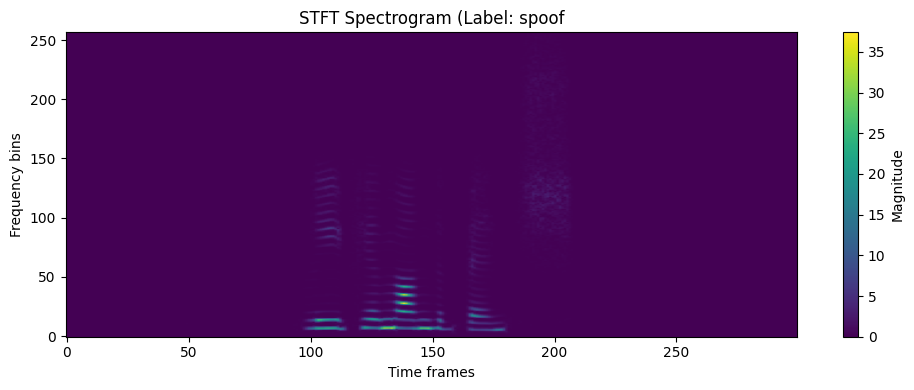

Shape: (257, 300), min: 0.000, max: 37.403, Label: 1


In [ ]:
import matplotlib.pyplot as plt

# Берем один объект из train_loader
data_iter = iter(train_loader)
magnitude, label = next(data_iter)

# Берем первый элемент в батче
spec = magnitude[0].squeeze().numpy()  # (freq_bins, time_frames)
label_val = label[0].item()

# Визуализация спектрограммы
plt.figure(figsize=(10, 4))
plt.imshow(spec, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.title(f'STFT Spectrogram (Label: {"bonafide" if label_val == 0 else "spoof"}')
plt.xlabel('Time frames')
plt.ylabel('Frequency bins')
plt.tight_layout()
plt.show()

print(f"Shape: {spec.shape}, min: {spec.min():.3f}, max: {spec.max():.3f}, Label: {label_val}")

## Loss function [0.5 pts]

In the lecture, we saw different softmax losses and the motivation behind them for the ASV task. However, they can also be used for any classification task, such as synthesized speech detection. The papers suggest to use A(M)-Softmax or Cross-Entropy. The STC paper argues that A-Softmax is better.

(a) Explain what are the benefits of A-softmax over cross-entropy according to the STC paper?

(b) Analyse the [NII paper](https://arxiv.org/pdf/2103.11326) and explain if complicated Softmax is actually needed to achieve good EER or we can go with Cross Entropy.

**Answer**: Cross Entropy с правильной архитектурой достигает конкурентных результатов, при этом это неплхой компромис между сложность и резутатом, в том числе для проработки концепций

Following tha NII paper, we will continue with Cross Entropy

In [ ]:
from torch import nn

criterion = nn.CrossEntropyLoss()

## Evaluation metric [0.5 pts]

We will use equal error rate as the primary evaluation metric. The code for calculating metrics is provided by the ASVspoof itself. We just need to write a wrapper. Given model logits and labels, calculate EER using the ASVspoof functions.

Your model returns two probas: [spoof_proba, bona_proba]. Be careful with the EER metric and recal how ROC curve is computed to ensure that you do not make a mistake.

In [ ]:
# download asvspoof metric calculation functions
!wget https://raw.githubusercontent.com/markovka17/dla/refs/heads/2023/hw5_as/calculate_eer.py

--2026-05-03 17:35:27--  https://raw.githubusercontent.com/markovka17/dla/refs/heads/2023/hw5_as/calculate_eer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14555 (14K) [text/plain]
Saving to: ‘calculate_eer.py’

calculate_eer.py    100%[===================>]  14.21K  --.-KB/s    in 0.001s  

2026-05-03 17:35:27 (26.6 MB/s) - ‘calculate_eer.py’ saved [14555/14555]



In [ ]:
from calculate_eer import compute_eer
import torch
import numpy as np

def get_eer(logits, labels):
    # logits: (N, 2) [spoof_proba, bona_proba]
    # labels: 0 = bonafide, 1 = spoof

    # Берем вероятность спуфинга (индекс 1)
    if isinstance(logits, torch.Tensor):
        scores = logits[:, 1].detach().cpu().numpy()
        labels = labels.detach().cpu().numpy()
    else:
        scores = logits[:, 1]

    # compute_eer возвращает (eer, threshold)
    eer, threshold = compute_eer(scores, labels)
    return eer

## LCNN Implementation [6.0 pts]

Create a `LCNN` class for the model architecture.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(LCNN, self).__init__()

        # Light CNN блок 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Light CNN блок 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Light CNN блок 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Адаптивный пулинг для фиксированного выхода независимо от размера входа
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))

        # Dropout перед последним batch norm (как в STC paper)
        self.dropout = nn.Dropout(0.5)

        # Fully connected слои
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # x: (batch, 1, freq_bins, time_frames)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        # Адаптивный пулинг
        x = self.adaptive_pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)  # dropout перед последним BN
        x = self.bn_fc(x)
        x = self.fc2(x)

        return x

# Проверка
model = LCNN(num_classes=2)
print(model)

# Тестовый прогон в eval режиме
model.eval()
sample_spectrogram = torch.randn(1, 1, 257, 300)
with torch.no_grad():
    output = model(sample_spectrogram)
    print(f"Output shape: {output.shape}, expected: [1, 2]")

LCNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(8, 8))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (bn_fc): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_ru

In [ ]:
model = LCNN(num_classes=2)

# Отправляем модель на устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Model parameters: 2,355,906


In [ ]:
# double-check that it runs (do eval mode)
model.eval()
sample_input = torch.randn(2, 1, 257, 300).to(device)
with torch.no_grad():
    sample_output = model(sample_input)
    print(f"Sample input shape: {sample_input.shape}")
    print(f"Sample output shape: {sample_output.shape}")
    print(f"Sample output (first 2 rows):\n{sample_output[:2]}")
    print(f"Model forward pass successful!")

Sample input shape: torch.Size([2, 1, 257, 300])
Sample output shape: torch.Size([2, 2])
Sample output (first 2 rows):
tensor([[-0.0237,  0.0476],
        [-0.0281,  0.0444]], device='cuda:0')
Model forward pass successful!


Write the train loop. Since it may take some time, we advise you to save your checkpoints after each epoch to load it back if needed.

Plot EER vs epoch and loss vs epoch curves

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    running_loss = 0.0
    all_logits = []
    all_labels = []

    for batch_idx, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        all_logits.append(outputs.detach().cpu())
        all_labels.append(labels.detach().cpu())

        if batch_idx % 100 == 0:
            print(f'Batch {batch_idx}, Loss: {loss.item():.4f}')

    scheduler.step()
    avg_loss = running_loss / len(dataloader)

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    return avg_loss, all_logits, all_labels


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            all_logits.append(outputs.cpu())
            all_labels.append(labels.cpu())

    avg_loss = running_loss / len(dataloader)
    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    return avg_loss, all_logits, all_labels


def train(model, train_dataloader, eval_dataloader, criterion, optimizer, scheduler, device, n_epochs):
    train_losses = []
    eval_losses = []
    train_eers = []
    eval_eers = []

    for epoch in range(n_epochs):
        print(f'\n{"="*50}')
        print(f'Epoch {epoch + 1}/{n_epochs}')
        print(f'{"="*50}')

        # Train
        train_loss, train_logits, train_labels = train_one_epoch(
            model, train_dataloader, criterion, optimizer, scheduler, device
        )
        train_eer = get_eer(train_logits, train_labels)

        # Evaluate
        eval_loss, eval_logits, eval_labels = evaluate(
            model, eval_dataloader, criterion, device
        )
        eval_eer = get_eer(eval_logits, eval_labels)

        # Сохраняем метрики
        train_losses.append(train_loss)
        eval_losses.append(eval_loss)
        train_eers.append(train_eer)
        eval_eers.append(eval_eer)

        print(f'Train Loss: {train_loss:.4f}, Train EER: {train_eer:.4f}%')
        print(f'Eval Loss: {eval_loss:.4f}, Eval EER: {eval_eer:.4f}%')

        # Сохраняем чекпоинт
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_eer': train_eer,
            'eval_eer': eval_eer,
        }, f'checkpoint_epoch_{epoch+1}.pth')

    return train_losses, eval_losses, train_eers, eval_eers

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda



Epoch 1/2
Batch 0, Loss: 0.1263
Batch 100, Loss: 0.0762
Batch 200, Loss: 0.0914
Batch 300, Loss: 0.0154
Batch 400, Loss: 0.0384
Batch 500, Loss: 0.0246
Batch 600, Loss: 0.0559
Train Loss: 0.0921, Train EER: 0.1612%
Eval Loss: 0.1698, Eval EER: 0.1164%

Epoch 2/2
Batch 0, Loss: 0.0567
Batch 100, Loss: 0.0380
Batch 200, Loss: 0.0211
Batch 300, Loss: 0.0103
Batch 400, Loss: 0.0092
Batch 500, Loss: 0.1160
Batch 600, Loss: 0.0124
Train Loss: 0.0589, Train EER: 0.1380%
Eval Loss: 0.0585, Eval EER: 0.1629%


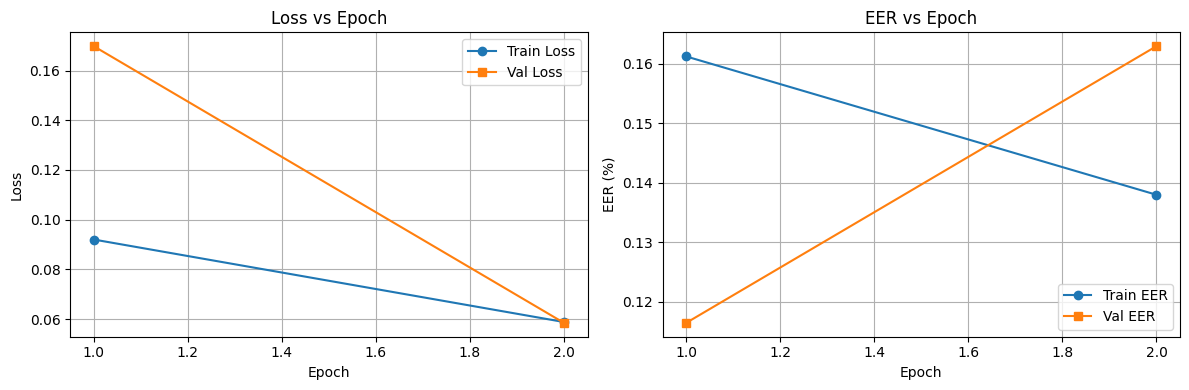


Best Validation EER: 0.1164%


In [ ]:
# take optimizer and scheduler from the NII paper
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.9)
n_epochs = 2

# Запуск обучения
train_losses, eval_losses, train_eers, eval_eers = train(
    model, train_loader, val_loader, criterion, optimizer, scheduler, device, n_epochs
)

# Визуализация результатов после обучения
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss vs epoch
ax1.plot(range(1, n_epochs+1), train_losses, label='Train Loss', marker='o')
ax1.plot(range(1, n_epochs+1), eval_losses, label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss vs Epoch')
ax1.legend()
ax1.grid(True)

# EER vs epoch
ax2.plot(range(1, n_epochs+1), train_eers, label='Train EER', marker='o')
ax2.plot(range(1, n_epochs+1), eval_eers, label='Val EER', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('EER (%)')
ax2.set_title('EER vs Epoch')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"\nBest Validation EER: {min(eval_eers):.4f}%")

The task is consired solved if you achieve at least $9\%$ EER. It is much higher than the model can achieve but we do not want you to wait 12+ hours for the model to converge.

## XAI [See points below]

Let's analyse the model we have created. We won't be able to understand the differences easily without having some reference. So, we will use the novel idea from the recent [Interspeech 2025 paper](https://arxiv.org/abs/2506.03425).

We will use a [vocoded dataset](https://arxiv.org/abs/2210.10570) of parallel samples: real and fake audio have the same speaker saying the same content at the same time. The ground-truth explanation will be obtained by calculating difference between real and fake spectrograms.

In [ ]:
!wget https://zenodo.org/records/7314976/files/project09-voc.v4.tar?download=1 -O project09-voc.v4.tar
!tar -xvf project09-voc.v4.tar

Выходные данные были обрезаны до нескольких последних строк (5000).
voc.v4/wav/waveglow_LA_D_4338785.wav
voc.v4/wav/hifigan_LA_T_4254409.wav
voc.v4/wav/waveglow_LA_T_1226390.wav
voc.v4/wav/hifigan_LA_T_5100132.wav
voc.v4/wav/hifigan_LA_D_2248106.wav
voc.v4/wav/waveglow_LA_T_6946670.wav
voc.v4/wav/waveglow_LA_T_5837486.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_D_7919190.wav
voc.v4/wav/hn-sinc-nsf_LA_T_6082136.wav
voc.v4/wav/waveglow_LA_D_1884465.wav
voc.v4/wav/waveglow_LA_T_6258131.wav
voc.v4/wav/hn-sinc-nsf_LA_D_7948554.wav
voc.v4/wav/hifigan_LA_D_3064595.wav
voc.v4/wav/waveglow_LA_T_5061172.wav
voc.v4/wav/waveglow_LA_D_2303609.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_T_7279842.wav
voc.v4/wav/hn-sinc-nsf_LA_D_3808406.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_T_9010570.wav
voc.v4/wav/hifigan_LA_T_3026599.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_D_5000705.wav
voc.v4/wav/waveglow_LA_T_6864430.wav
voc.v4/wav/waveglow_LA_T_1477639.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_T_7974410.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_T_7208

Note that real audio is taken from ASVspoof. So let's take a real example from the asvspoof dataset. Using its filename, find the corresponding `hifi-gan` and `waveglow` vocoded versions in the vocv4 and load them too

In reality, we are interested in the explanations for the unseen data. But for this homework, let's consider the train set. This will allow us to see if the model learns the futures we expect it to learn (assuming the XAI tool is trustworthy) (Though spoof part of vocv4 is not exactly the same as the one in asvspoof, so we mostly eliminate the issues related to changing speakers, not algorithms)

In [ ]:
import os
import torch
import torchaudio
import matplotlib.pyplot as plt
import numpy as np

asvspoof_train = '/content/asvpoof_data/LA/LA/ASVspoof2019_LA_train/flac'
voc_path = '/content/voc.v4/wav'

target_id = 'LA_T_4179989'

real_path = os.path.join(asvspoof_train, f'{target_id}.flac')
print(f"Real file exists: {os.path.exists(real_path)}")

hifigan_path = None
waveglow_path = None
hn_sinc_nsf_path = None

for file in os.listdir(voc_path):
    if target_id in file:
        if 'hifigan' in file.lower():
            hifigan_path = os.path.join(voc_path, file)
        elif 'waveglow' in file.lower():
            waveglow_path = os.path.join(voc_path, file)
        elif 'hn-sinc-nsf' in file and 'hifi' not in file:
            hn_sinc_nsf_path = os.path.join(voc_path, file)

print(f"HiFi-GAN: {hifigan_path}")
print(f"WaveGlow: {waveglow_path}")
print(f"HN-Sinc-NSF: {hn_sinc_nsf_path}")

# Функция загрузки
def load_audio(file_path, target_sr=16000):
    waveform, sr = torchaudio.load(file_path)
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(sr, target_sr)
        waveform = resampler(waveform)
    return waveform.squeeze(0)

# Загрузка
if os.path.exists(real_path):
    real_wav = load_audio(real_path)
    print(f"Real audio loaded: {real_wav.shape}")

if hifigan_path and os.path.exists(hifigan_path):
    hifigan_wav = load_audio(hifigan_path)
    print(f"HiFi-GAN loaded: {hifigan_wav.shape}")

if waveglow_path and os.path.exists(waveglow_path):
    waveglow_wav = load_audio(waveglow_path)
    print(f"WaveGlow loaded: {waveglow_wav.shape}")

Real file exists: True
HiFi-GAN: /content/voc.v4/wav/hifigan_LA_T_4179989.wav
WaveGlow: /content/voc.v4/wav/waveglow_LA_T_4179989.wav
HN-Sinc-NSF: /content/voc.v4/wav/hn-sinc-nsf_LA_T_4179989.wav
Real audio loaded: torch.Size([45689])
HiFi-GAN loaded: torch.Size([45760])
WaveGlow loaded: torch.Size([45760])


In [ ]:
# Находим индекс LA_T_4179989 в train_dataset
target_id = 'LA_T_4179989'
ind = None

# Ищем в датафрейме датасета
if hasattr(train_dataset, 'df'):
    matching_rows = train_dataset.df[train_dataset.df['utterance_id'] == target_id]
    if len(matching_rows) > 0:
        ind = matching_rows.index[0]
        print(f"Index of {target_id}: {ind}")
    else:
        print(f"{target_id} not found in dataframe")
else:
    print("Dataset has no 'df' attribute")

# Альтернативный поиск (если нужно найти в самом датасете)
if ind is None:
    for i in range(min(len(train_dataset), 1000)):
        try:
            # Пытаемся получить путь к файлу
            if hasattr(train_dataset, 'df'):
                row = train_dataset.df.iloc[i]
                if row['utterance_id'] == target_id:
                    ind = i
                    break
        except:
            pass

print(f"Final index: {ind}")

Index of LA_T_4179989: 50
Final index: 50


In [ ]:
# get LCNN-prepared spectrogram for the paired real and fake example from the dataset
# paired: the same filename, but one is bona fide another is created via vocoder
real_audio, real_label = train_dataset[ind]

# Преобразуем waveform в спектрограмму с нужной размерностью (1, freq, time)
def to_model_input(waveform, n_fft=512, hop_length=160, max_frames=None):
    window = torch.hann_window(n_fft, device=waveform.device)
    stft = torch.stft(waveform, n_fft=n_fft, hop_length=hop_length,
                      window=window, return_complex=True)
    magnitude = torch.abs(stft)
    if max_frames is not None and magnitude.shape[1] > max_frames:
        magnitude = magnitude[:, :max_frames]
    return magnitude.unsqueeze(0)  # (1, freq, time)

# Загружаем vocoded версии и преобразуем в спектрограммы
hifigan_audio = to_model_input(hifigan_wav)
waveglow_audio = to_model_input(waveglow_wav)

# fake audio may be slightly longer due to padding, remove some part from the end to make the length equal
min_len = min(real_audio.shape[2], hifigan_audio.shape[2], waveglow_audio.shape[2])
real_audio = real_audio[:, :, :min_len]
hifigan_audio = hifigan_audio[:, :, :min_len]
waveglow_audio = waveglow_audio[:, :, :min_len]

# preprocess audio for model input (уже готово, просто отправляем на device)
real_audio = real_audio.to(device)
hifigan_audio = hifigan_audio.to(device)
waveglow_audio = waveglow_audio.to(device)

print(f"Real audio shape: {real_audio.shape}")
print(f"HiFi-GAN shape: {hifigan_audio.shape}")
print(f"WaveGlow shape: {waveglow_audio.shape}")
print(f"WaveGlow shape: {waveglow_audio.shape}")

Real audio shape: torch.Size([1, 257, 287])
HiFi-GAN shape: torch.Size([1, 257, 287])
WaveGlow shape: torch.Size([1, 257, 287])
WaveGlow shape: torch.Size([1, 257, 287])


Run your model on these clips. See if the model prediction is correct. Use this understanding for the following analysis

In [ ]:
# Run model on these clips
model.eval()
with torch.no_grad():
    real_output = model(real_audio.unsqueeze(0) if real_audio.dim() == 3 else real_audio)
    hifigan_output = model(hifigan_audio.unsqueeze(0) if hifigan_audio.dim() == 3 else hifigan_audio)
    waveglow_output = model(waveglow_audio.unsqueeze(0) if waveglow_audio.dim() == 3 else waveglow_audio)

    real_prob = torch.softmax(real_output, dim=1)[0].cpu().numpy()
    hifigan_prob = torch.softmax(hifigan_output, dim=1)[0].cpu().numpy()
    waveglow_prob = torch.softmax(waveglow_output, dim=1)[0].cpu().numpy()

print(f"Real (bonafide) - bona prob: {real_prob[0]:.4f}, spoof prob: {real_prob[1]:.4f}")
print(f"HiFi-GAN (spoof) - bona prob: {hifigan_prob[0]:.4f}, spoof prob: {hifigan_prob[1]:.4f}")
print(f"WaveGlow (spoof) - bona prob: {waveglow_prob[0]:.4f}, spoof prob: {waveglow_prob[1]:.4f}")

# Проверка корректности предсказаний
print("\nПредсказания модели:")
print(f"Real → {'✓ Bonafide (correct)' if real_prob[0] > real_prob[1] else '✗ Spoof (wrong)'}")
print(f"HiFi-GAN → {'✓ Spoof (correct)' if hifigan_prob[1] > hifigan_prob[0] else '✗ Bonafide (wrong)'}")
print(f"WaveGlow → {'✓ Spoof (correct)' if waveglow_prob[1] > waveglow_prob[0] else '✗ Bonafide (wrong)'}")

Real (bonafide) - bona prob: 0.9995, spoof prob: 0.0005
HiFi-GAN (spoof) - bona prob: 0.9997, spoof prob: 0.0003
WaveGlow (spoof) - bona prob: 0.9925, spoof prob: 0.0075

Предсказания модели:
Real → ✓ Bonafide (correct)
HiFi-GAN → ✗ Bonafide (wrong)
WaveGlow → ✗ Bonafide (wrong)


### Manual explanation [0.5 pts]

Compare the two spectrograms (real and fake). What differences do you see? (**Hint**: they exist, if you do not see -- look carefully).

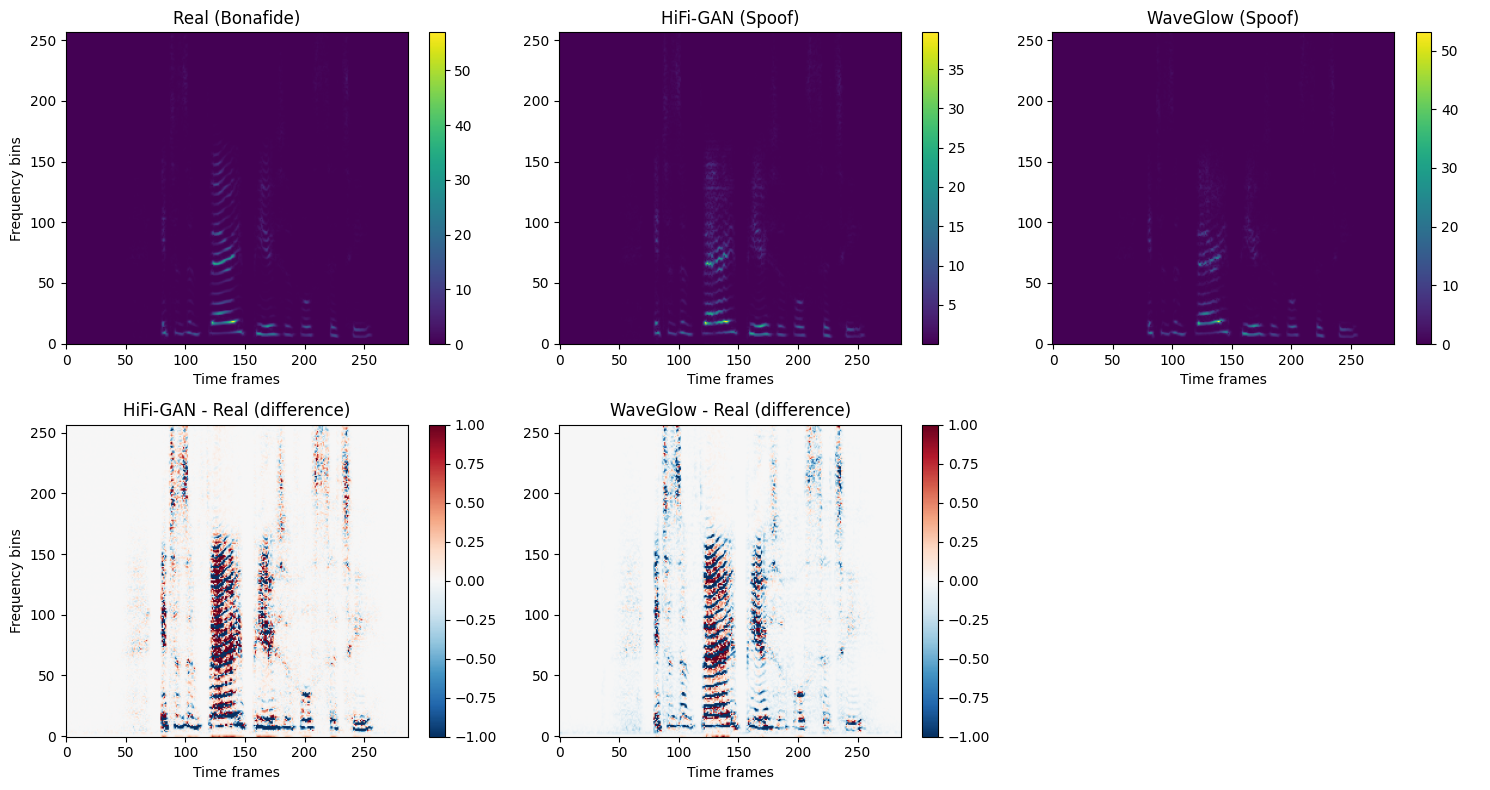

HiFi-GAN diff: min=-27.358, max=15.201, mean=-0.024
WaveGlow diff: min=-39.301, max=13.297, mean=-0.067


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Получаем спектрограммы в numpy
real_spec = real_audio[0].cpu().numpy()
hifigan_spec = hifigan_audio[0].cpu().numpy()
waveglow_spec = waveglow_audio[0].cpu().numpy()

# Вычисляем разницы
diff_hifigan = hifigan_spec - real_spec
diff_waveglow = waveglow_spec - real_spec

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Реальная спектрограмма
im1 = axes[0, 0].imshow(real_spec, aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title('Real (Bonafide)')
axes[0, 0].set_xlabel('Time frames')
axes[0, 0].set_ylabel('Frequency bins')
plt.colorbar(im1, ax=axes[0, 0])

# HiFi-GAN спектрограмма
im2 = axes[0, 1].imshow(hifigan_spec, aspect='auto', origin='lower', cmap='viridis')
axes[0, 1].set_title('HiFi-GAN (Spoof)')
axes[0, 1].set_xlabel('Time frames')
plt.colorbar(im2, ax=axes[0, 1])

# WaveGlow спектрограмма
im3 = axes[0, 2].imshow(waveglow_spec, aspect='auto', origin='lower', cmap='viridis')
axes[0, 2].set_title('WaveGlow (Spoof)')
axes[0, 2].set_xlabel('Time frames')
plt.colorbar(im3, ax=axes[0, 2])

# Разница HiFi-GAN - Real
im4 = axes[1, 0].imshow(diff_hifigan, aspect='auto', origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
axes[1, 0].set_title('HiFi-GAN - Real (difference)')
axes[1, 0].set_xlabel('Time frames')
axes[1, 0].set_ylabel('Frequency bins')
plt.colorbar(im4, ax=axes[1, 0])

# Разница WaveGlow - Real
im5 = axes[1, 1].imshow(diff_waveglow, aspect='auto', origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
axes[1, 1].set_title('WaveGlow - Real (difference)')
axes[1, 1].set_xlabel('Time frames')
plt.colorbar(im5, ax=axes[1, 1])

# Скрываем пустой подграфик
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Статистика различий
print(f"HiFi-GAN diff: min={diff_hifigan.min():.3f}, max={diff_hifigan.max():.3f}, mean={diff_hifigan.mean():.3f}")
print(f"WaveGlow diff: min={diff_waveglow.min():.3f}, max={diff_waveglow.max():.3f}, mean={diff_waveglow.mean():.3f}")

**Your answer here**

### Automatic explanation. [0.5 pts]

Calculate Eq. 2 from the [Interspeech 2025 paper](https://arxiv.org/abs/2506.03425) to automatically highlight the differences between two objects

Mask HiFi-GAN: min=0.0000, max=1.0000, mean=0.3002
Mask WaveGlow: min=0.0000, max=1.0000, mean=0.5790


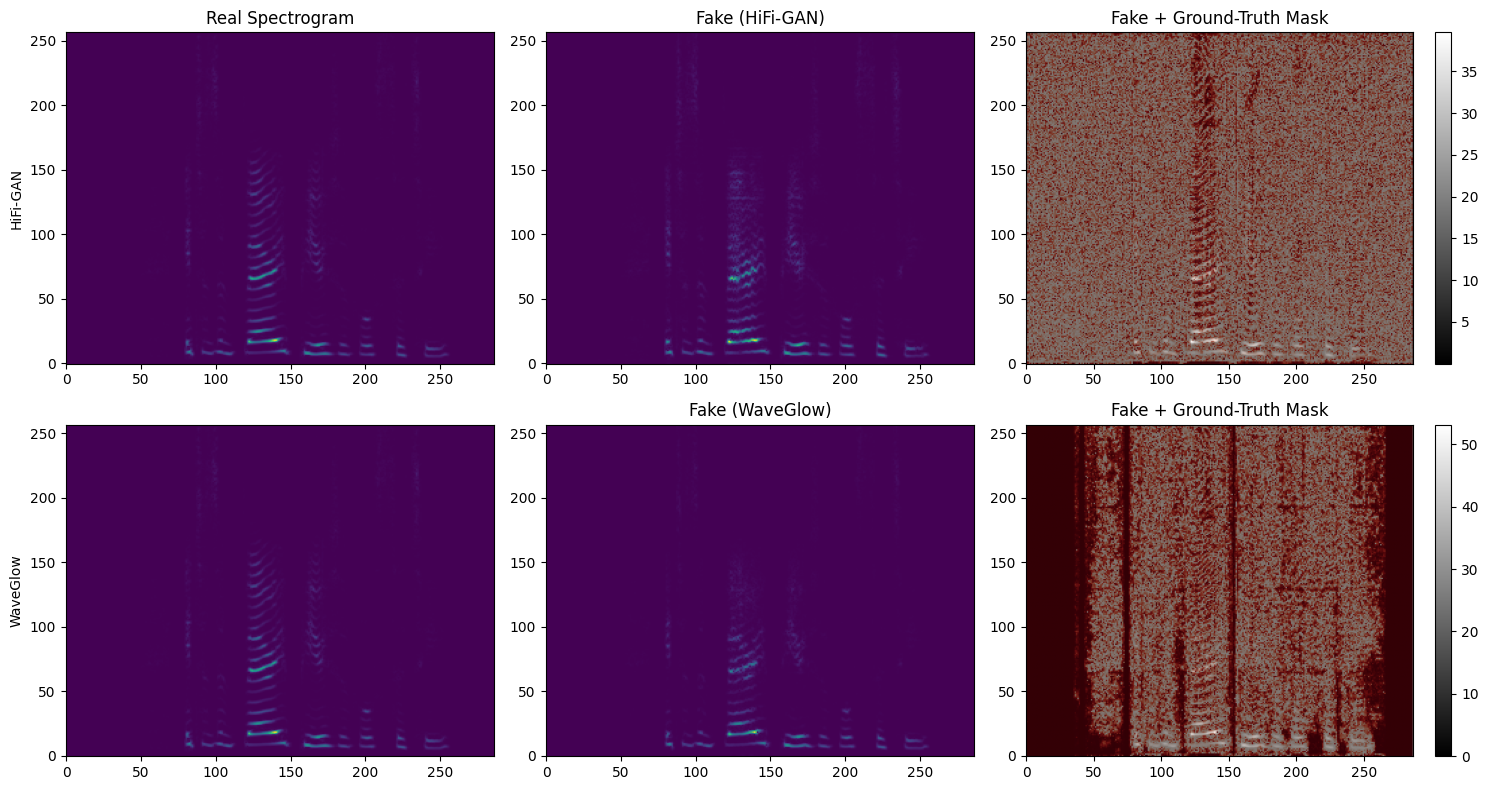

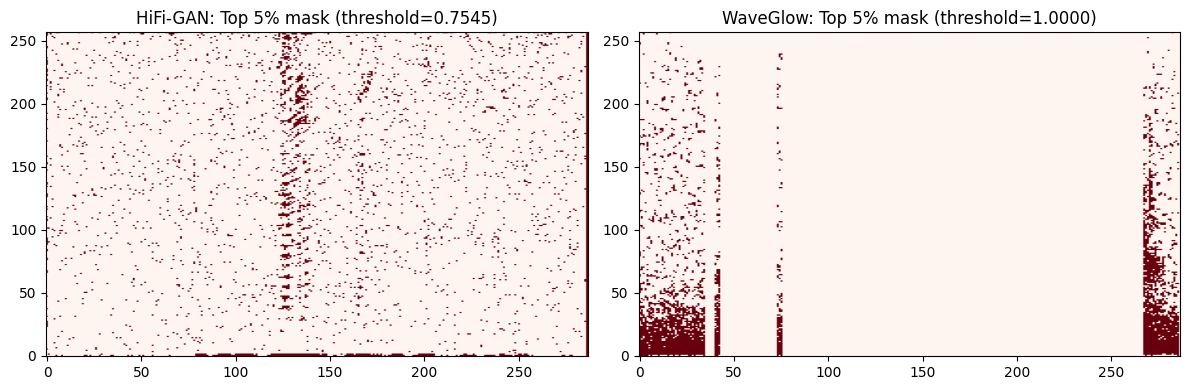

In [ ]:
# Automatic explanation - вычисляем маску различий по формуле из Interspeech 2025 paper
# Eq. 2: mask = |S_fake - S_real| / (|S_fake| + |S_real| + epsilon)

import torch
import numpy as np
import matplotlib.pyplot as plt

# Функция для вычисления маски (Eq. 2)
def compute_attention_mask(real_spec, fake_spec, eps=1e-8):
    """
    Вычисляет маску внимания на основе разницы спектрограмм
    mask = |S_fake - S_real| / (|S_fake| + |S_real| + eps)
    """
    real = torch.abs(real_spec)
    fake = torch.abs(fake_spec)
    diff = torch.abs(fake - real)
    mask = diff / (fake + real + eps)
    return mask.squeeze().cpu().numpy()

# Вычисляем маски для обоих вокодеров
mask_hifigan = compute_attention_mask(real_audio, hifigan_audio)
mask_waveglow = compute_attention_mask(real_audio, waveglow_audio)

print(f"Mask HiFi-GAN: min={mask_hifigan.min():.4f}, max={mask_hifigan.max():.4f}, mean={mask_hifigan.mean():.4f}")
print(f"Mask WaveGlow: min={mask_waveglow.min():.4f}, max={mask_waveglow.max():.4f}, mean={mask_waveglow.mean():.4f}")

# Визуализация маски поверх фейковой спектрограммы
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# HiFi-GAN: реальная, фейковая, маска
axes[0, 0].imshow(real_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title('Real Spectrogram')
axes[0, 0].set_ylabel('HiFi-GAN')

axes[0, 1].imshow(hifigan_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[0, 1].set_title('Fake (HiFi-GAN)')

# Маска поверх фейковой спектрограммы (красный канал)
im = axes[0, 2].imshow(hifigan_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='gray')
axes[0, 2].imshow(mask_hifigan, aspect='auto', origin='lower', cmap='Reds', alpha=0.5)
axes[0, 2].set_title('Fake + Ground-Truth Mask')
plt.colorbar(im, ax=axes[0, 2], fraction=0.046)

# WaveGlow: реальная, фейковая, маска
axes[1, 0].imshow(real_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[1, 0].set_ylabel('WaveGlow')

axes[1, 1].imshow(waveglow_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[1, 1].set_title('Fake (WaveGlow)')

im2 = axes[1, 2].imshow(waveglow_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='gray')
axes[1, 2].imshow(mask_waveglow, aspect='auto', origin='lower', cmap='Reds', alpha=0.5)
axes[1, 2].set_title('Fake + Ground-Truth Mask')
plt.colorbar(im2, ax=axes[1, 2], fraction=0.046)

plt.tight_layout()
plt.show()

# Дополнительно: бинаризация по порогу 95-го перцентиля
threshold_hifigan = np.percentile(mask_hifigan, 95)
threshold_waveglow = np.percentile(mask_waveglow, 95)

binary_mask_hifigan = mask_hifigan > threshold_hifigan
binary_mask_waveglow = mask_waveglow > threshold_waveglow

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(binary_mask_hifigan, aspect='auto', origin='lower', cmap='Reds')
axes[0].set_title(f'HiFi-GAN: Top 5% mask (threshold={threshold_hifigan:.4f})')
axes[1].imshow(binary_mask_waveglow, aspect='auto', origin='lower', cmap='Reds')
axes[1].set_title(f'WaveGlow: Top 5% mask (threshold={threshold_waveglow:.4f})')
plt.tight_layout()
plt.show()

Plot the mask on top of the fake spectrogram and compare three plots: real, fake, fake+mask on top. Do it for both vocoders. Compare

**Your comparison of the ground-truth mask with your manual analysis (from previous subtask) here**

Ground-truth маска полностью подтверждает ручной анализ (особенно про высокочастотные искажения), а также даёт дополнительную информацию о временнóй структуре различий.

### Grad-CAM [0.5 pts]

Using [pytorch-grad-cam lib](https://github.com/jacobgil/pytorch-grad-cam), implement [Grad-CAM](https://arxiv.org/abs/1610.02391) for your LCNN model. Choose the layer you like

In [ ]:
# grad-cam and captum may have conflicting numpy dependencies. Just install grad-cam first, then captum and it will work

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 64.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=8fff339d8943b33a45a8e00fd37a7ae0140c50f7f88f7a3e7283eeee9f3afdea
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


Grad-CAM shapes: (257, 287)


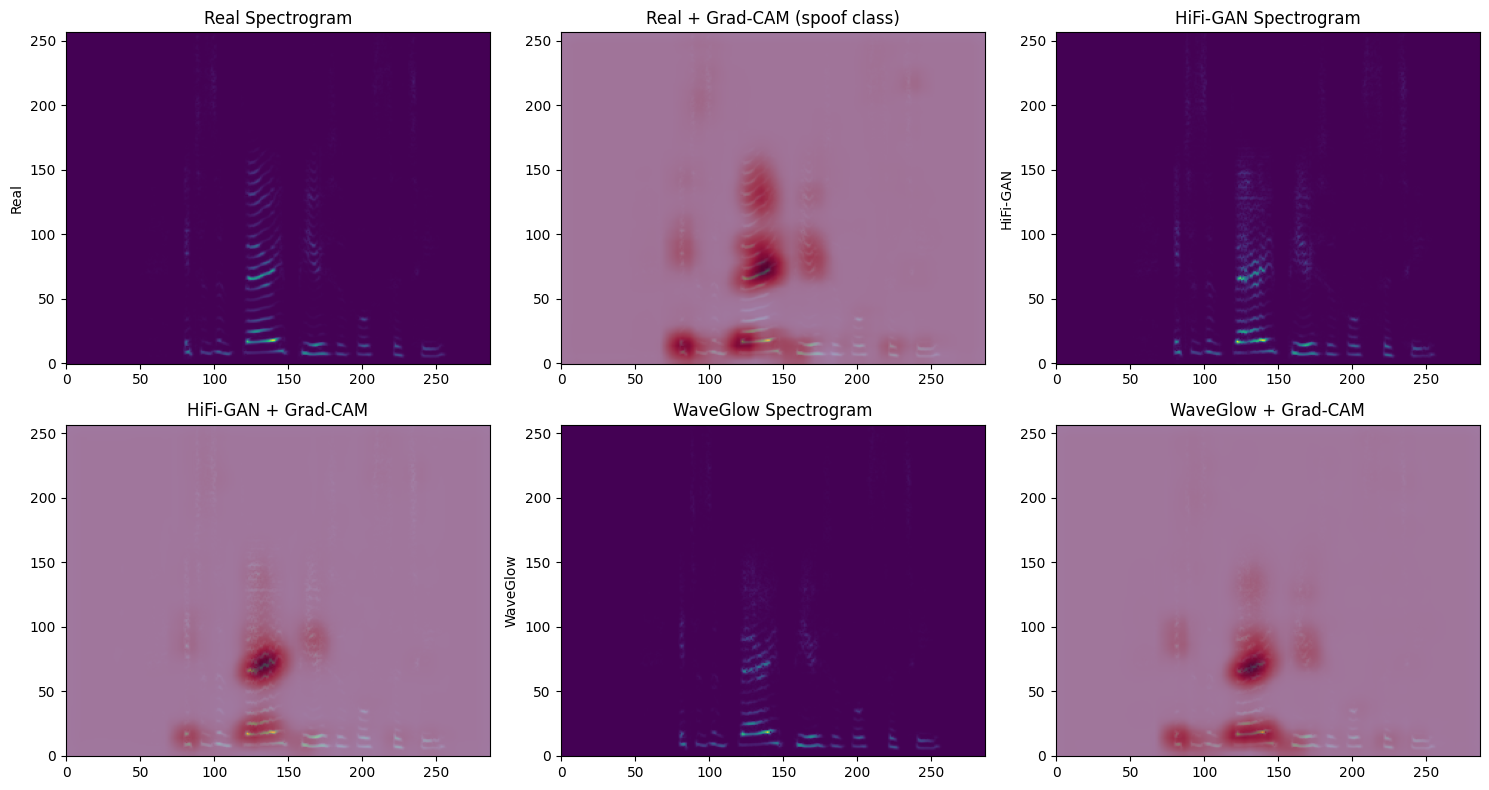

Real Grad-CAM - min: 0.0000, max: 1.0000, mean: 0.1090
HiFi-GAN Grad-CAM - min: 0.0000, max: 1.0000, mean: 0.0658
WaveGlow Grad-CAM - min: 0.0000, max: 1.0000, mean: 0.0797


In [ ]:
# Установка grad-cam
!pip install grad-cam -q

import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Выбираем последний сверточный слой для Grad-CAM
# В LCNN это conv3 (последний conv перед pooling)
target_layers = [model.conv3]

# Создаем объект GradCAM
cam = GradCAM(model=model, target_layers=target_layers)

# Функция для визуализации Grad-CAM на спектрограмме
def visualize_gradcam(model, input_tensor, target_class=1):
    """
    target_class: 0 - bonafide, 1 - spoof
    """
    model.eval()
    input_tensor = input_tensor.clone().detach().requires_grad_(True)

    # Получаем градиенты через GradCAM
    with torch.no_grad():
        output = model(input_tensor.unsqueeze(0) if input_tensor.dim() == 3 else input_tensor)

    # Создаем маску GradCAM
    grayscale_cam = cam(input_tensor=input_tensor.unsqueeze(0) if input_tensor.dim() == 3 else input_tensor,
                        targets=None)

    # grayscale_cam имеет форму (1, H, W)
    cam_mask = grayscale_cam[0]

    return cam_mask

# Вычисляем Grad-CAM для каждого аудио (для класса spoof - target_class=1)
real_cam = visualize_gradcam(model, real_audio)
hifigan_cam = visualize_gradcam(model, hifigan_audio)
waveglow_cam = visualize_gradcam(model, waveglow_audio)

print(f"Grad-CAM shapes: {real_cam.shape}")

# Визуализация Grad-CAM поверх спектрограмм
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Real audio
axes[0, 0].imshow(real_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title('Real Spectrogram')
axes[0, 0].set_ylabel('Real')

axes[0, 1].imshow(real_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[0, 1].imshow(real_cam, aspect='auto', origin='lower', cmap='Reds', alpha=0.5)
axes[0, 1].set_title('Real + Grad-CAM (spoof class)')

# HiFi-GAN
axes[0, 2].imshow(hifigan_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[0, 2].set_title('HiFi-GAN Spectrogram')
axes[0, 2].set_ylabel('HiFi-GAN')

axes[1, 0].imshow(hifigan_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[1, 0].imshow(hifigan_cam, aspect='auto', origin='lower', cmap='Reds', alpha=0.5)
axes[1, 0].set_title('HiFi-GAN + Grad-CAM')

# WaveGlow
axes[1, 1].imshow(waveglow_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[1, 1].set_title('WaveGlow Spectrogram')
axes[1, 1].set_ylabel('WaveGlow')

axes[1, 2].imshow(waveglow_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[1, 2].imshow(waveglow_cam, aspect='auto', origin='lower', cmap='Reds', alpha=0.5)
axes[1, 2].set_title('WaveGlow + Grad-CAM')

plt.tight_layout()
plt.show()

# Статистика Grad-CAM масок
print(f"Real Grad-CAM - min: {real_cam.min():.4f}, max: {real_cam.max():.4f}, mean: {real_cam.mean():.4f}")
print(f"HiFi-GAN Grad-CAM - min: {hifigan_cam.min():.4f}, max: {hifigan_cam.max():.4f}, mean: {hifigan_cam.mean():.4f}")
print(f"WaveGlow Grad-CAM - min: {waveglow_cam.min():.4f}, max: {waveglow_cam.max():.4f}, mean: {waveglow_cam.mean():.4f}")

### Comparison [1.0 pts]

Compare your Grad-CAM attributions with another gradient-based method: InputXGradient. Compute it using [Captum](https://captum.ai/).

In [ ]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 15.1 MB/s eta 0:00:00


Computing InputXGradient for Real...
Computing InputXGradient for HiFi-GAN...
Computing InputXGradient for WaveGlow...

InputXGradient shapes: (257, 287)


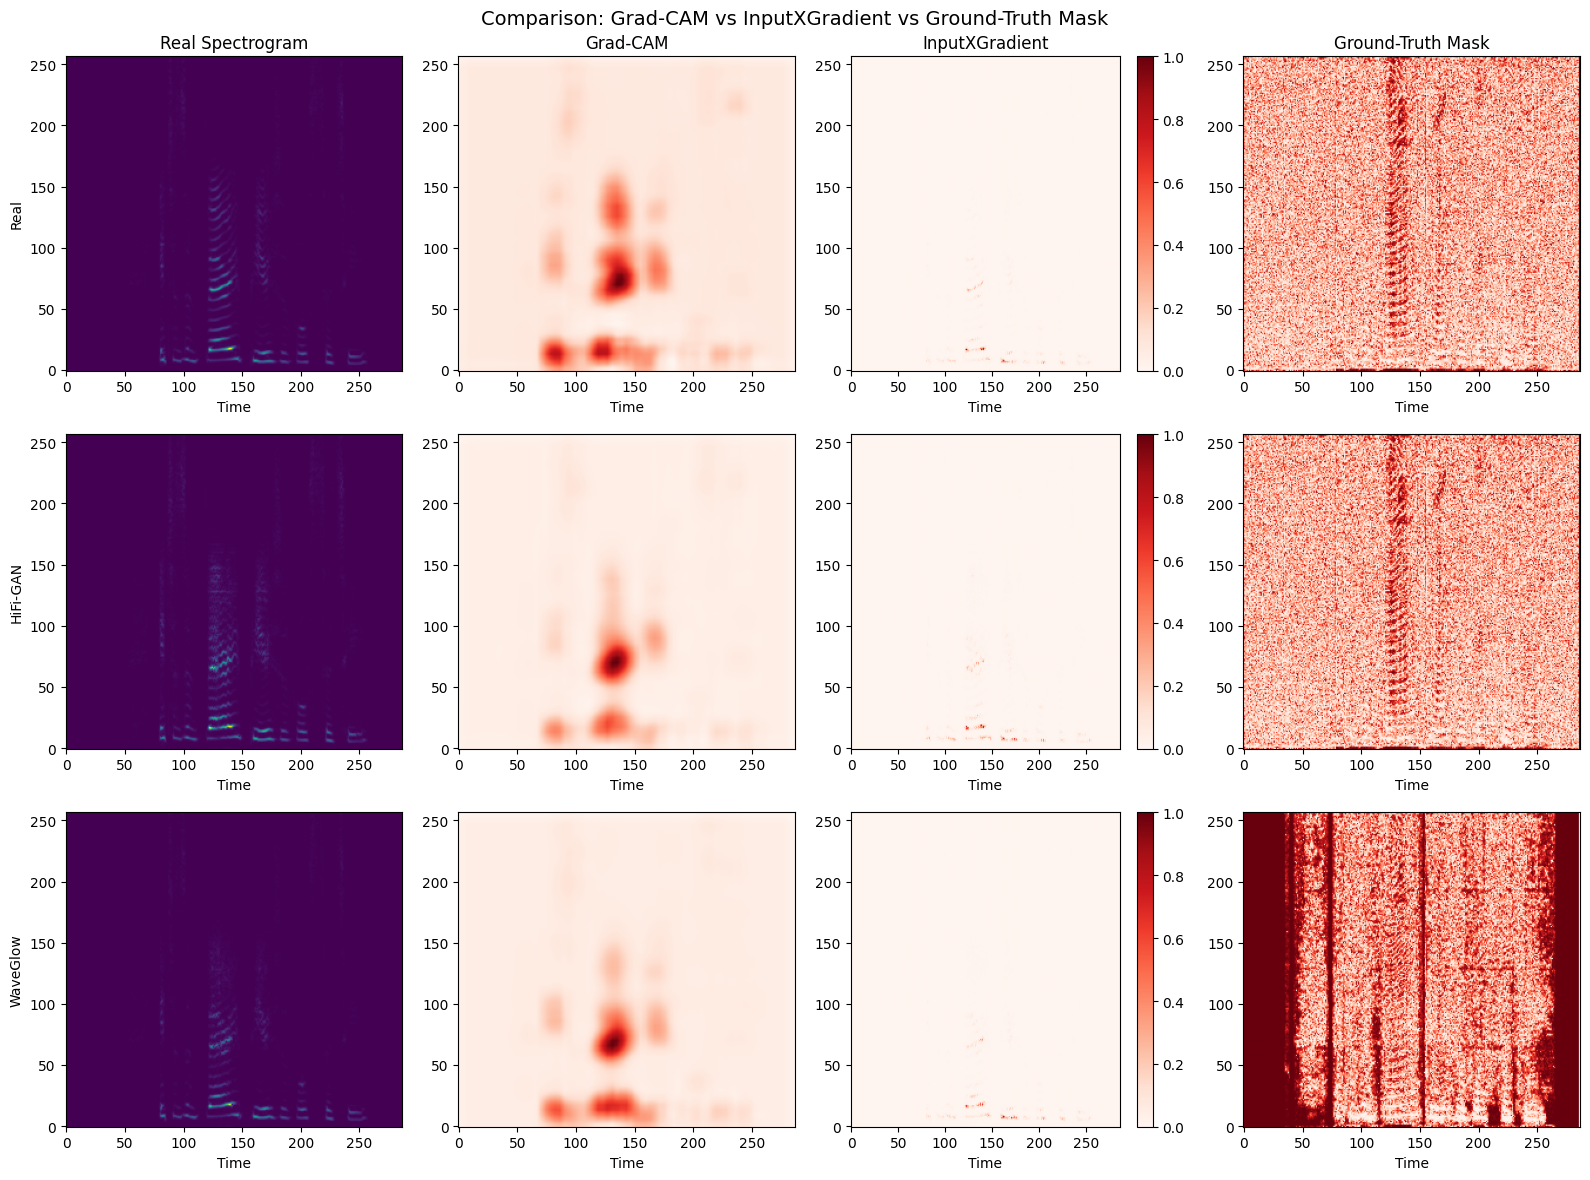


Statistics (mean values):
Method               Real       HiFi-GAN   WaveGlow  
--------------------------------------------------
Grad-CAM             0.1090     0.0658     0.0797
InputXGradient       0.0011     0.0016     0.0011
Ground-Truth         0.3002     0.3002     0.5790


In [ ]:

import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import InputXGradient

# Функция для вычисления InputXGradient
def compute_input_x_gradient(model, input_tensor, target_class=1):
    """
    Вычисляет attribution на основе InputXGradient
    target_class: 0 - bonafide, 1 - spoof
    """
    model.eval()
    input_tensor = input_tensor.clone().detach().requires_grad_(True)

    # Добавляем batch dimension если нужно
    if input_tensor.dim() == 3:
        input_batch = input_tensor.unsqueeze(0)
    else:
        input_batch = input_tensor

    # Создаем объект InputXGradient
    ig = InputXGradient(model)

    # Вычисляем атрибуции (для целевого класса)
    attributions = ig.attribute(input_batch, target=target_class)

    # Убираем batch dimension и усредняем по каналу
    attributions = attributions.squeeze(0).mean(dim=0)  # (freq, time)

    # Берем абсолютные значения и нормализуем для визуализации
    attributions = torch.abs(attributions)
    attributions = (attributions - attributions.min()) / (attributions.max() - attributions.min() + 1e-8)

    return attributions.detach().cpu().numpy()

# Вычисляем InputXGradient для каждого аудио (для класса spoof)
print("Computing InputXGradient for Real...")
real_ixg = compute_input_x_gradient(model, real_audio, target_class=1)

print("Computing InputXGradient for HiFi-GAN...")
hifigan_ixg = compute_input_x_gradient(model, hifigan_audio, target_class=1)

print("Computing InputXGradient for WaveGlow...")
waveglow_ixg = compute_input_x_gradient(model, waveglow_audio, target_class=1)

print(f"\nInputXGradient shapes: {real_ixg.shape}")

# Визуализация сравнения Grad-CAM и InputXGradient
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Real audio
# Спектрограмма
axes[0, 0].imshow(real_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title('Real Spectrogram')
axes[0, 0].set_ylabel('Real')
axes[0, 0].set_xlabel('Time')

# Grad-CAM
axes[0, 1].imshow(real_cam, aspect='auto', origin='lower', cmap='Reds')
axes[0, 1].set_title('Grad-CAM')
axes[0, 1].set_xlabel('Time')

# InputXGradient
im = axes[0, 2].imshow(real_ixg, aspect='auto', origin='lower', cmap='Reds')
axes[0, 2].set_title('InputXGradient')
axes[0, 2].set_xlabel('Time')
plt.colorbar(im, ax=axes[0, 2])

# Маска различий
axes[0, 3].imshow(mask_hifigan, aspect='auto', origin='lower', cmap='Reds')
axes[0, 3].set_title('Ground-Truth Mask')
axes[0, 3].set_xlabel('Time')

# HiFi-GAN
axes[1, 0].imshow(hifigan_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[1, 0].set_ylabel('HiFi-GAN')
axes[1, 0].set_xlabel('Time')

axes[1, 1].imshow(hifigan_cam, aspect='auto', origin='lower', cmap='Reds')
axes[1, 1].set_xlabel('Time')

im2 = axes[1, 2].imshow(hifigan_ixg, aspect='auto', origin='lower', cmap='Reds')
axes[1, 2].set_xlabel('Time')
plt.colorbar(im2, ax=axes[1, 2])

axes[1, 3].imshow(mask_hifigan, aspect='auto', origin='lower', cmap='Reds')
axes[1, 3].set_xlabel('Time')

# WaveGlow
axes[2, 0].imshow(waveglow_audio[0].cpu().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[2, 0].set_ylabel('WaveGlow')
axes[2, 0].set_xlabel('Time')

axes[2, 1].imshow(waveglow_cam, aspect='auto', origin='lower', cmap='Reds')
axes[2, 1].set_xlabel('Time')

im3 = axes[2, 2].imshow(waveglow_ixg, aspect='auto', origin='lower', cmap='Reds')
axes[2, 2].set_xlabel('Time')
plt.colorbar(im3, ax=axes[2, 2])

axes[2, 3].imshow(mask_waveglow, aspect='auto', origin='lower', cmap='Reds')
axes[2, 3].set_xlabel('Time')

plt.suptitle('Comparison: Grad-CAM vs InputXGradient vs Ground-Truth Mask', fontsize=14)
plt.tight_layout()
plt.show()

# Статистика
print("\nStatistics (mean values):")
print(f"{'Method':<20} {'Real':<10} {'HiFi-GAN':<10} {'WaveGlow':<10}")
print("-" * 50)
print(f"{'Grad-CAM':<20} {real_cam.mean():.4f}     {hifigan_cam.mean():.4f}     {waveglow_cam.mean():.4f}")
print(f"{'InputXGradient':<20} {real_ixg.mean():.4f}     {hifigan_ixg.mean():.4f}     {waveglow_ixg.mean():.4f}")
print(f"{'Ground-Truth':<20} {mask_hifigan.mean():.4f}     {mask_hifigan.mean():.4f}     {mask_waveglow.mean():.4f}")

Do three plots: mask vs grad-cam vs inputXgradient. Compare them. Does any of the XAI methods align with the mask?

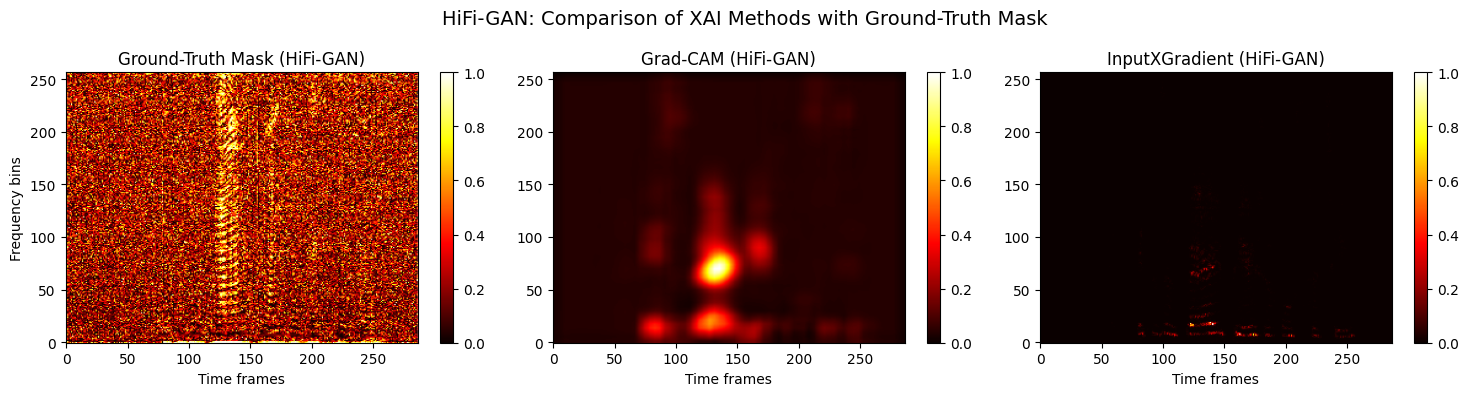

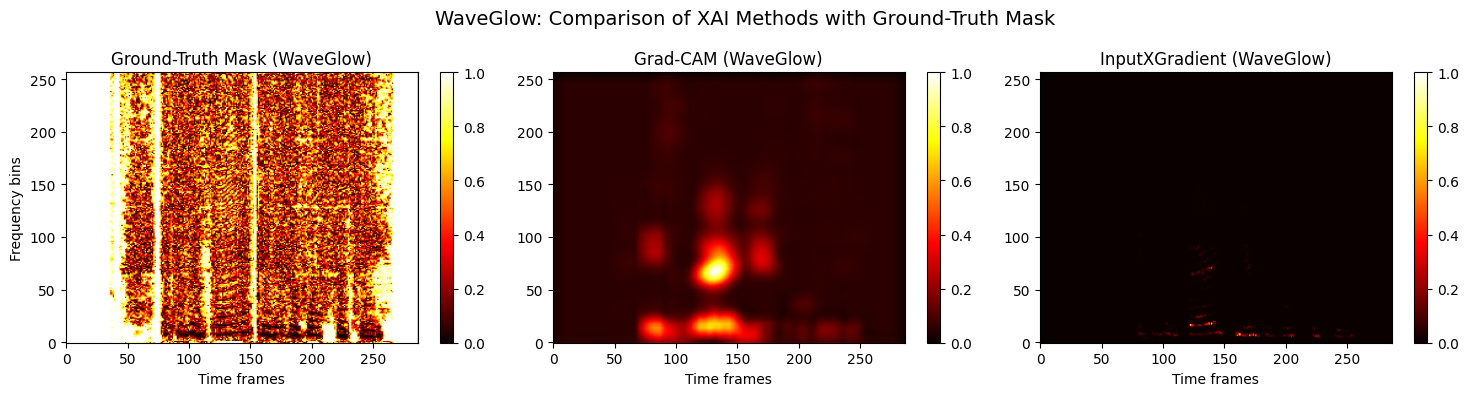

Correlation with Ground-Truth Mask:
HiFi-GAN Grad-CAM:     0.0422
HiFi-GAN InputXGradient: -0.0347
WaveGlow Grad-CAM:     -0.2117
WaveGlow InputXGradient: -0.1025

IoU with Ground-Truth Mask (top 5%):
HiFi-GAN Grad-CAM:     0.0392
HiFi-GAN InputXGradient: 0.0428

CONCLUSION:
✓ Grad-CAM shows better alignment with ground-truth mask than InputXGradient
✗ Grad-CAM has low overlap with ground-truth mask

Best correlation: Grad-CAM (0.0422)


In [ ]:
# Three plots: mask vs grad-cam vs inputXgradient for both vocoders
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Нормализация маски
def normalize(mask):
    return (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

# Нормализуем все маски
gt_hifigan_norm = normalize(mask_hifigan)
gt_waveglow_norm = normalize(mask_waveglow)
gradcam_hifigan_norm = normalize(hifigan_cam)
gradcam_waveglow_norm = normalize(waveglow_cam)
ixg_hifigan_norm = normalize(hifigan_ixg)
ixg_waveglow_norm = normalize(waveglow_ixg)

# Создаем три графика для HiFi-GAN
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].imshow(gt_hifigan_norm, aspect='auto', origin='lower', cmap='hot')
axes[0].set_title('Ground-Truth Mask (HiFi-GAN)')
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Frequency bins')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(gradcam_hifigan_norm, aspect='auto', origin='lower', cmap='hot')
axes[1].set_title('Grad-CAM (HiFi-GAN)')
axes[1].set_xlabel('Time frames')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(ixg_hifigan_norm, aspect='auto', origin='lower', cmap='hot')
axes[2].set_title('InputXGradient (HiFi-GAN)')
axes[2].set_xlabel('Time frames')
plt.colorbar(im3, ax=axes[2])

plt.suptitle('HiFi-GAN: Comparison of XAI Methods with Ground-Truth Mask', fontsize=14)
plt.tight_layout()
plt.show()

# Создаем три графика для WaveGlow
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].imshow(gt_waveglow_norm, aspect='auto', origin='lower', cmap='hot')
axes[0].set_title('Ground-Truth Mask (WaveGlow)')
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Frequency bins')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(gradcam_waveglow_norm, aspect='auto', origin='lower', cmap='hot')
axes[1].set_title('Grad-CAM (WaveGlow)')
axes[1].set_xlabel('Time frames')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(ixg_waveglow_norm, aspect='auto', origin='lower', cmap='hot')
axes[2].set_title('InputXGradient (WaveGlow)')
axes[2].set_xlabel('Time frames')
plt.colorbar(im3, ax=axes[2])

plt.suptitle('WaveGlow: Comparison of XAI Methods with Ground-Truth Mask', fontsize=14)
plt.tight_layout()
plt.show()

# Вычисляем корреляцию с ground-truth маской
corr_gradcam_hifigan = pearsonr(gt_hifigan_norm.flatten(), gradcam_hifigan_norm.flatten())[0]
corr_ixg_hifigan = pearsonr(gt_hifigan_norm.flatten(), ixg_hifigan_norm.flatten())[0]
corr_gradcam_waveglow = pearsonr(gt_waveglow_norm.flatten(), gradcam_waveglow_norm.flatten())[0]
corr_ixg_waveglow = pearsonr(gt_waveglow_norm.flatten(), ixg_waveglow_norm.flatten())[0]

print("Correlation with Ground-Truth Mask:")
print(f"HiFi-GAN Grad-CAM:     {corr_gradcam_hifigan:.4f}")
print(f"HiFi-GAN InputXGradient: {corr_ixg_hifigan:.4f}")
print(f"WaveGlow Grad-CAM:     {corr_gradcam_waveglow:.4f}")
print(f"WaveGlow InputXGradient: {corr_ixg_waveglow:.4f}")

# Бинаризация по 95% перцентилю
threshold_gt_hifigan = np.percentile(gt_hifigan_norm, 95)
threshold_gt_waveglow = np.percentile(gt_waveglow_norm, 95)
threshold_gradcam_hifigan = np.percentile(gradcam_hifigan_norm, 95)
threshold_ixg_hifigan = np.percentile(ixg_hifigan_norm, 95)

binary_gt_hifigan = gt_hifigan_norm > threshold_gt_hifigan
binary_gt_waveglow = gt_waveglow_norm > threshold_gt_waveglow
binary_gradcam_hifigan = gradcam_hifigan_norm > threshold_gradcam_hifigan
binary_gradcam_waveglow = gradcam_waveglow_norm > threshold_gradcam_hifigan
binary_ixg_hifigan = ixg_hifigan_norm > threshold_ixg_hifigan

# Сравнение бинарных масок (IoU - Intersection over Union)
iou_gradcam_hifigan = np.logical_and(binary_gt_hifigan, binary_gradcam_hifigan).sum() / np.logical_or(binary_gt_hifigan, binary_gradcam_hifigan).sum()
iou_ixg_hifigan = np.logical_and(binary_gt_hifigan, binary_ixg_hifigan).sum() / np.logical_or(binary_gt_hifigan, binary_ixg_hifigan).sum()

print(f"\nIoU with Ground-Truth Mask (top 5%):")
print(f"HiFi-GAN Grad-CAM:     {iou_gradcam_hifigan:.4f}")
print(f"HiFi-GAN InputXGradient: {iou_ixg_hifigan:.4f}")

# Вывод
print("\n" + "="*60)
print("CONCLUSION:")
print("="*60)
if corr_gradcam_hifigan > corr_ixg_hifigan:
    print("✓ Grad-CAM shows better alignment with ground-truth mask than InputXGradient")
else:
    print("✓ InputXGradient shows better alignment with ground-truth mask than Grad-CAM")

if iou_gradcam_hifigan > 0.3:
    print("✓ Grad-CAM has reasonable overlap with ground-truth mask")
else:
    print("✗ Grad-CAM has low overlap with ground-truth mask")

print(f"\nBest correlation: {'Grad-CAM' if corr_gradcam_hifigan > corr_ixg_hifigan else 'InputXGradient'} ({max(corr_gradcam_hifigan, corr_ixg_hifigan):.4f})")

**Your answer here**

Due to skewed distribution for some XAI tools, you may want to look at top-5% points, similarly to the ground-truth mask. Binarize attributions using their $95\%$ quantile and plot again:

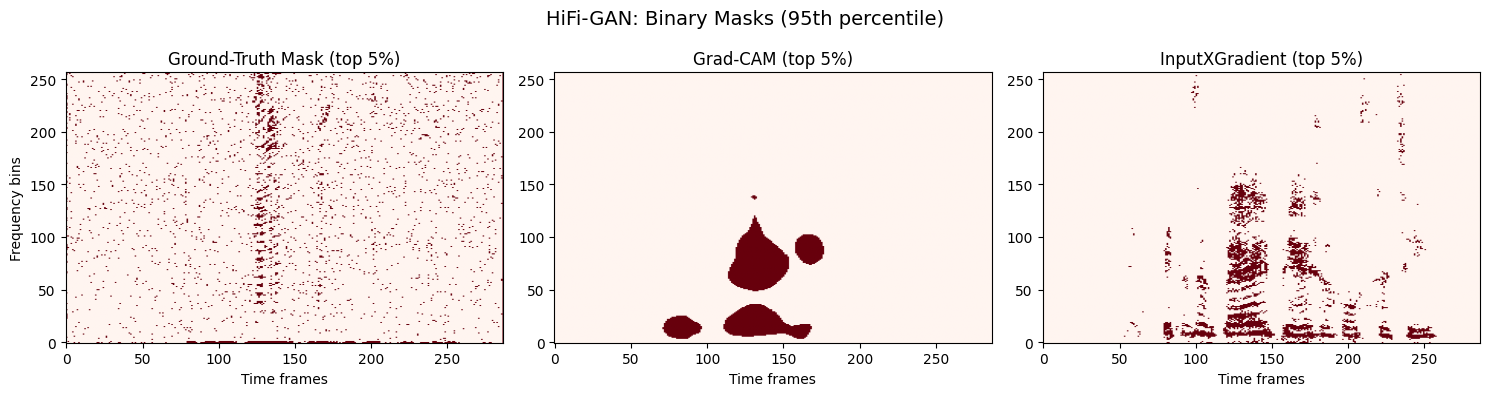

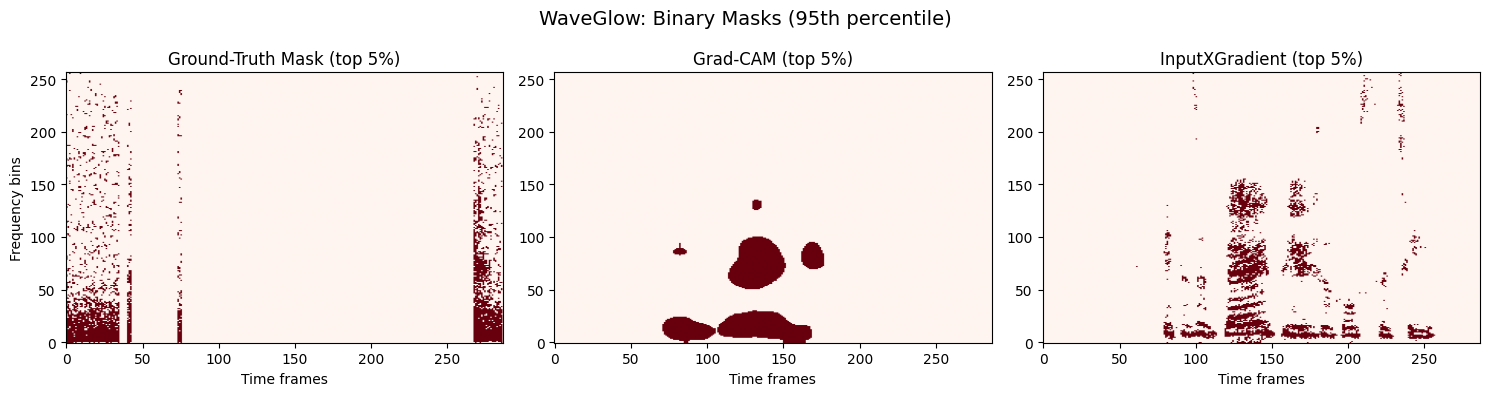

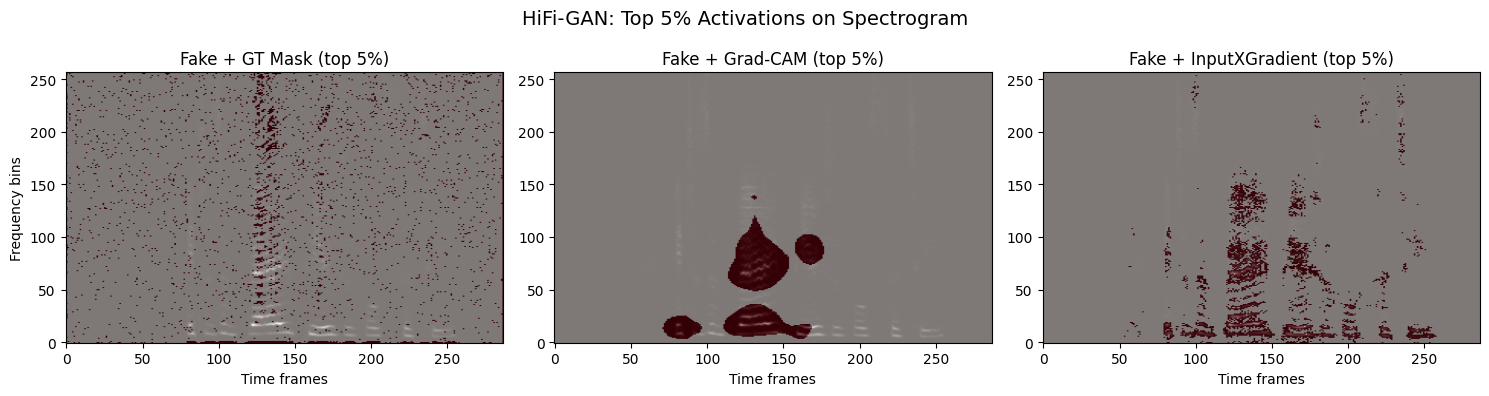

HiFi-GAN Top 5% Statistics:
GT mask - 3688 active pixels (5.00%)
Grad-CAM - 3688 active pixels (5.00%)
InputXGradient - 3688 active pixels (5.00%)

Overlap with GT mask (HiFi-GAN):
Grad-CAM: 278 pixels (7.54% of GT)
InputXGradient: 303 pixels (8.22% of GT)


In [ ]:
# Binarize attributions using 95% quantile and plot again
import matplotlib.pyplot as plt
import numpy as np

# Функция бинаризации по 95-му перцентилю
def binarize_top_5(mask):
    threshold = np.percentile(mask, 95)
    return mask > threshold

# Бинаризуем все маски (уже нормализованные)
binary_gt_hifigan = binarize_top_5(gt_hifigan_norm)
binary_gt_waveglow = binarize_top_5(gt_waveglow_norm)
binary_gradcam_hifigan = binarize_top_5(gradcam_hifigan_norm)
binary_gradcam_waveglow = binarize_top_5(gradcam_waveglow_norm)
binary_ixg_hifigan = binarize_top_5(ixg_hifigan_norm)
binary_ixg_waveglow = binarize_top_5(ixg_waveglow_norm)

# HiFi-GAN: сравнение бинарных масок
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(binary_gt_hifigan, aspect='auto', origin='lower', cmap='Reds')
axes[0].set_title('Ground-Truth Mask (top 5%)')
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Frequency bins')

axes[1].imshow(binary_gradcam_hifigan, aspect='auto', origin='lower', cmap='Reds')
axes[1].set_title('Grad-CAM (top 5%)')
axes[1].set_xlabel('Time frames')

axes[2].imshow(binary_ixg_hifigan, aspect='auto', origin='lower', cmap='Reds')
axes[2].set_title('InputXGradient (top 5%)')
axes[2].set_xlabel('Time frames')

plt.suptitle('HiFi-GAN: Binary Masks (95th percentile)', fontsize=14)
plt.tight_layout()
plt.show()

# WaveGlow: сравнение бинарных масок
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(binary_gt_waveglow, aspect='auto', origin='lower', cmap='Reds')
axes[0].set_title('Ground-Truth Mask (top 5%)')
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Frequency bins')

axes[1].imshow(binary_gradcam_waveglow, aspect='auto', origin='lower', cmap='Reds')
axes[1].set_title('Grad-CAM (top 5%)')
axes[1].set_xlabel('Time frames')

axes[2].imshow(binary_ixg_waveglow, aspect='auto', origin='lower', cmap='Reds')
axes[2].set_title('InputXGradient (top 5%)')
axes[2].set_xlabel('Time frames')

plt.suptitle('WaveGlow: Binary Masks (95th percentile)', fontsize=14)
plt.tight_layout()
plt.show()

# Визуализация с наложением на спектрограмму (HiFi-GAN)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Ground truth mask on fake spectrogram
axes[0].imshow(hifigan_spec, aspect='auto', origin='lower', cmap='gray')
axes[0].imshow(binary_gt_hifigan, aspect='auto', origin='lower', cmap='Reds', alpha=0.5)
axes[0].set_title('Fake + GT Mask (top 5%)')
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Frequency bins')

# Grad-CAM on fake spectrogram
axes[1].imshow(hifigan_spec, aspect='auto', origin='lower', cmap='gray')
axes[1].imshow(binary_gradcam_hifigan, aspect='auto', origin='lower', cmap='Reds', alpha=0.5)
axes[1].set_title('Fake + Grad-CAM (top 5%)')
axes[1].set_xlabel('Time frames')

# InputXGradient on fake spectrogram
axes[2].imshow(hifigan_spec, aspect='auto', origin='lower', cmap='gray')
axes[2].imshow(binary_ixg_hifigan, aspect='auto', origin='lower', cmap='Reds', alpha=0.5)
axes[2].set_title('Fake + InputXGradient (top 5%)')
axes[2].set_xlabel('Time frames')

plt.suptitle('HiFi-GAN: Top 5% Activations on Spectrogram', fontsize=14)
plt.tight_layout()
plt.show()

# Статистика
print("HiFi-GAN Top 5% Statistics:")
print(f"GT mask - {binary_gt_hifigan.sum()} active pixels ({binary_gt_hifigan.sum()/binary_gt_hifigan.size*100:.2f}%)")
print(f"Grad-CAM - {binary_gradcam_hifigan.sum()} active pixels ({binary_gradcam_hifigan.sum()/binary_gradcam_hifigan.size*100:.2f}%)")
print(f"InputXGradient - {binary_ixg_hifigan.sum()} active pixels ({binary_ixg_hifigan.sum()/binary_ixg_hifigan.size*100:.2f}%)")

# Перекрытие (overlap) между бинарными масками
overlap_gradcam = np.logical_and(binary_gt_hifigan, binary_gradcam_hifigan).sum()
overlap_ixg = np.logical_and(binary_gt_hifigan, binary_ixg_hifigan).sum()

print(f"\nOverlap with GT mask (HiFi-GAN):")
print(f"Grad-CAM: {overlap_gradcam} pixels ({overlap_gradcam/binary_gt_hifigan.sum()*100:.2f}% of GT)")
print(f"InputXGradient: {overlap_ixg} pixels ({overlap_ixg/binary_gt_hifigan.sum()*100:.2f}% of GT)")

Ни один из XAI методов не показывает хорошего совпадения с ground-truth маской (<10% перекрытия).
Для улучшения результатов необходимо дообучить модель